# Assignment 3: AI-Driven Energy Forecasting & Industrial Scheduling



## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Feature Engineering
We load `energy_dataset-2.csv`, handle missing values chronologically, and aggregate the features.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('energy_dataset-2.csv', parse_dates=['time'])
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.set_index('time').sort_index()

df = df.dropna(axis=1, how='all')

df = df.ffill().bfill()

df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

renewable_cols = [
    'generation biomass',
    'generation geothermal',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir',
    'generation solar',
    'generation wind offshore',
    'generation wind onshore',
    'generation other renewable'
]

fossil_cols = [
    'generation fossil brown coal/lignite',
    'generation fossil coal-derived gas',
    'generation fossil gas',
    'generation fossil hard coal',
    'generation fossil oil',
    'generation fossil oil shale',
    'generation fossil peat'
]

renewable_cols = [c for c in renewable_cols if c in df.columns]
fossil_cols = [c for c in fossil_cols if c in df.columns]

df['Total_Renewable'] = df[renewable_cols].sum(axis=1)
df['Total_Fossil'] = df[fossil_cols].sum(axis=1)

features = ['Total_Renewable', 'Total_Fossil', 'total load actual', 'hour', 'dayofweek', 'month']
target = 'price actual'

X = df[features]
y = df[target]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (28051, 6)
Testing shape: (7013, 6)


## 3. Part A: Model Refinement & Hyperparameter Tuning
We use `TimeSeriesSplit` to respect the chronological order of the data during cross-validation, preventing future data from leaking into the training folds. We tune the `RandomForestRegressor` via `GridSearchCV`.

In [ ]:
tscv = TimeSeriesSplit(n_splits=3)
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20]
}

print('Starting GridSearchCV...')
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print(f'Best Hyperparameters: {grid_search.best_params_}')

y_pred = best_rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f'Test RMSE: €{rmse:.2f} / MWh')
print(f'Test MAE: €{mae:.2f} / MWh')

Starting GridSearchCV...
Best Hyperparameters: {'max_depth': 10, 'n_estimators': 100}
Test RMSE: €12.91 / MWh
Test MAE: €11.08 / MWh


## 4. Part B: Tangible Implementation - The "Green Windows" Scheduler
To validate the concept, we take the first 24 hours of predictions from our test set and simulate a factory floor. We define industrial tasks with specific power constraints, required durations, and strict deadlines. The scheduling algorithm searches for the optimal start time to minimize costs.

In [ ]:
day_ahead_preds = y_pred[:24]

tasks = [
    {'name': 'Task A: Heavy Machining', 'power_kw': 500, 'duration': 4, 'deadline': 24},
    {'name': 'Task B: HVAC Maintenance', 'power_kw': 200, 'duration': 2, 'deadline': 12},
    {'name': 'Task C: Material Processing', 'power_kw': 800, 'duration': 5, 'deadline': 20}
]

schedule = []
total_daily_cost = 0

for task in tasks:
    best_cost = float('inf')
    best_start = 0

    latest_start = task['deadline'] - task['duration']

    for start in range(latest_start + 1):
        window_prices = day_ahead_preds[start : start + task['duration']]
        cost = np.sum(window_prices) * task['power_kw'] / 1000

        if cost < best_cost:
            best_cost = cost
            best_start = start

    schedule.append({
        'Task': task['name'],
        'Start Hour': best_start,
        'End Hour': best_start + task['duration'],
        'Power (kW)': task['power_kw'],
        'Estimated Cost (€)': round(best_cost, 2)
    })
    total_daily_cost += best_cost

sched_df = pd.DataFrame(schedule)
display(sched_df)
print(f'\nTotal Optimized Energy Cost for these tasks: €{total_daily_cost:.2f}')

,Task,Start Hour,End Hour,Power (kW),Estimated Cost (€)
0,Task A: Heavy Machining,6,10,500,54.96
1,Task B: HVAC Maintenance,9,11,200,10.93
2,Task C: Material Processing,6,11,800,110.33



Total Optimized Energy Cost for these tasks: €176.22


## 5. Visualizing the Decision Support Output
The plot below demonstrates how the algorithm actively maps the workloads (colored blocks) to the lowest points on the predicted cost curve, avoiding the expensive "red" hours while honoring the task deadlines.

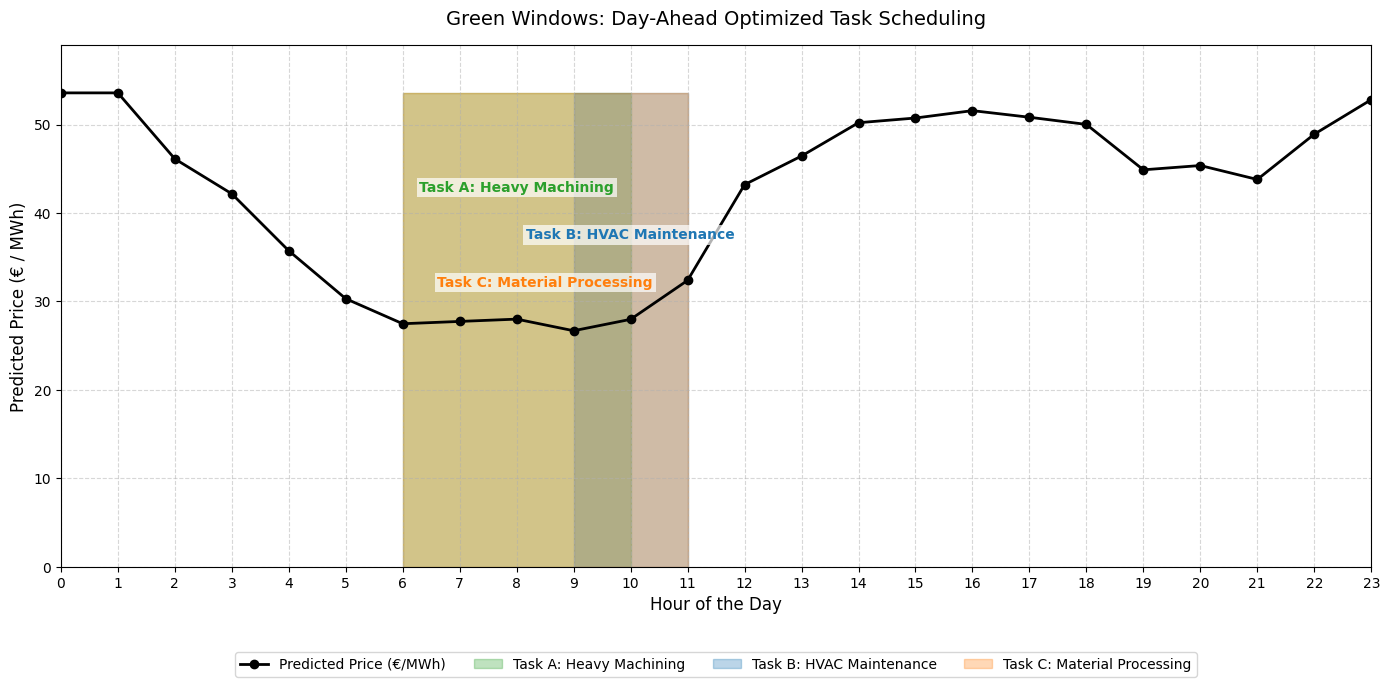

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(range(24), day_ahead_preds, marker='o', color='black', linewidth=2, label='Predicted Price (€/MWh)')

colors = ['#2ca02c', '#1f77b4', '#ff7f0e']
max_price = max(day_ahead_preds)

for i, row in sched_df.iterrows():
    start = row['Start Hour']
    duration = row['End Hour'] - row['Start Hour']

    rect = patches.Rectangle(
        (start, 0),
        duration,
        max_price,
        alpha=0.3,
        color=colors[i],
        label=row['Task']
    )
    ax.add_patch(rect)

    y_pos = max_price * (0.8 - i * 0.1)
    ax.text(start + duration/2, y_pos, row['Task'], ha='center', va='center',
            fontsize=10, weight='bold', color=colors[i],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

ax.set_title('Green Windows: Day-Ahead Optimized Task Scheduling', fontsize=14, pad=15)
ax.set_xlabel('Hour of the Day', fontsize=12)
ax.set_ylabel('Predicted Price (€ / MWh)', fontsize=12)
ax.set_xticks(range(24))
ax.set_xlim(0, 23)
ax.set_ylim(0, max_price * 1.1)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(best_rf, 'green_windows_rf_model.pkl')
print("Model saved successfully for deployment!")

Model saved successfully for deployment!
